In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from PIL import Image

img = Image.open("/content/drive/MyDrive/hanyang/eachneuron.jpg").convert("RGB")

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [5]:
torch.manual_seed(1)

In [3]:
from torchvision.transforms import v2
from torchvision.io import decode_image
img = decode_image("/content/drive/MyDrive/hanyang/eachneuron.jpg")

In [13]:
print(torch.max(img), torch.min(img))

tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8)


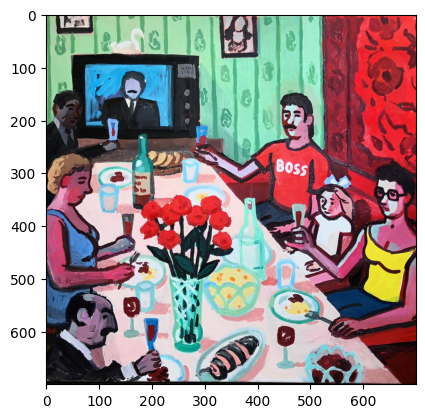

In [22]:
y = img.detach().float().cpu()
y = y.permute(1,2,0).numpy().astype(np.uint8)
plt.imshow(y)
plt.show()

In [83]:
def plot_tensor(x):
    """
    tensor -> np.array to plot after an decode_image
    """
    y = x.detach().float().cpu()
    y = y.permute(1,2,0).numpy()
    if y.max()<=1:
            return y                 # imshow gère les floats [0,1]
    return y.astype(np.uint8)


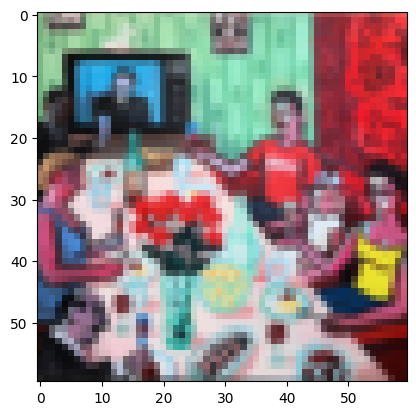

In [66]:
transform = v2.Resize(size=(60, 60), antialias=True)
torch.manual_seed(1)
out = transform(img)
plt.imshow(plot_tensor(out))
plt.show()

In [ ]:
transforms = v2.Compose([
    v2.Resize(size=(500, 500), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
plt.imshow(plot_tensor(transforms(img)))
plt.show()

TypeError: Input tensor should be a float tensor. Got torch.uint8.